## DenseNet121 Implementation - DenseNet121



###                     Data Loading and Preprocessing

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay,
 )

DATASET_ROOT = r"F:\Durjoy_Work\Final_Dataset"
IMG_SIZE = 224
RANDOM_STATE = 415
BATCH_SIZE = 32
EPOCHS = 50

class_folders = sorted([
    d for d in os.listdir(DATASET_ROOT)
    if os.path.isdir(os.path.join(DATASET_ROOT, d))
])

print("Classes:", class_folders)
print("Number of classes:", len(class_folders))


Classes: ['Bacterial Leaf Blight', 'Brown Spot', 'Healthy Rice Leaf', 'Leaf Blast', 'Leaf scald', 'Sheath Blight']
Number of classes: 6


In [2]:
records = []
images = []
labels = []

for label_name in class_folders:
    folder = os.path.join(DATASET_ROOT, label_name)
    for file_name in os.listdir(folder):
        image_path = os.path.join(folder, file_name)
        img = cv2.imread(image_path)
        if img is None:
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        images.append(img)
        labels.append(label_name)
        records.append((label_name, image_path))

images = np.array(images, dtype="float32")
labels = np.array(labels)

df = pd.DataFrame(records, columns=["label", "image_path"])
print("Total images:", len(images))
print(df.head())

Total images: 4264
                   label                                         image_path
0  Bacterial Leaf Blight  F:\Durjoy_Work\Final_Dataset\Bacterial Leaf Bl...
1  Bacterial Leaf Blight  F:\Durjoy_Work\Final_Dataset\Bacterial Leaf Bl...
2  Bacterial Leaf Blight  F:\Durjoy_Work\Final_Dataset\Bacterial Leaf Bl...
3  Bacterial Leaf Blight  F:\Durjoy_Work\Final_Dataset\Bacterial Leaf Bl...
4  Bacterial Leaf Blight  F:\Durjoy_Work\Final_Dataset\Bacterial Leaf Bl...


In [3]:
class_names = sorted(np.unique(labels))
label_to_id = {name: idx for idx, name in enumerate(class_names)}
y = np.array([label_to_id[label] for label in labels], dtype=np.int32)

print("Class mapping:", label_to_id)
print("Label counts:")
print(df["label"].value_counts())

Class mapping: {'Bacterial Leaf Blight': 0, 'Brown Spot': 1, 'Healthy Rice Leaf': 2, 'Leaf Blast': 3, 'Leaf scald': 4, 'Sheath Blight': 5}
Label counts:
label
Leaf Blast               836
Brown Spot               791
Bacterial Leaf Blight    729
Leaf scald               718
Healthy Rice Leaf        642
Sheath Blight            548
Name: count, dtype: int64


In [4]:
# 70/20/10 split: train/val/test
train_x, temp_x, train_y, temp_y = train_test_split(
    images, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

val_x, test_x, val_y, test_y = train_test_split(
    temp_x, temp_y, test_size=0.33, random_state=RANDOM_STATE, stratify=temp_y
)

print("Train:", train_x.shape, train_y.shape)
print("Val  :", val_x.shape, val_y.shape)
print("Test :", test_x.shape, test_y.shape)

Train: (2984, 224, 224, 3) (2984,)
Val  : (857, 224, 224, 3) (857,)
Test : (423, 224, 224, 3) (423,)


###  DenseNet121 Model Training

In [5]:
from tensorflow.keras import layers
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

num_classes = len(class_names)

train_x_pp = tf.keras.applications.densenet.preprocess_input(train_x.copy())
val_x_pp = tf.keras.applications.densenet.preprocess_input(val_x.copy())
test_x_pp = tf.keras.applications.densenet.preprocess_input(test_x.copy())

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest",
)

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
base_model = DenseNet121(
    include_top=False,
    weights="imagenet",
    input_tensor=inputs,
    pooling=None,
)
base_model.trainable = True

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1,
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1,
)

checkpoint = ModelCheckpoint(
    "best_densenet121.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1,
)

hist = model.fit(
    datagen.flow(train_x_pp, train_y, batch_size=BATCH_SIZE),
    steps_per_epoch=max(1, len(train_x_pp) // BATCH_SIZE),
    epochs=EPOCHS,
    validation_data=(val_x_pp, val_y),
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1,
)

print("Training complete.")



29084464/29084464 [==============================] - 14s 0us/step
Epoch 1/50


93/93 [==============================] - ETA: 0s - loss: 1.2855 - accuracy: 0.5149 
Epoch 1: val_accuracy improved from -inf to 0.66278, saving model to best_densenet121.keras
93/93 [==============================] - 1116s 12s/step - loss: 1.2855 - accuracy: 0.5149 - val_loss: 0.8405 - val_accuracy: 0.6628 - lr: 1.0000e-04
Epoch 2/50
93/93 [==============================] - ETA: 0s - loss: 0.7887 - accuracy: 0.7049
Epoch 2: val_accuracy improved from 0.66278 to 0.79697, saving model to best_densenet121.keras
93/93 [==============================] - 958s 10s/step - loss: 0.7887 - accuracy: 0.7049 - val_loss: 0.5709 - val_accuracy: 0.7970 - lr: 1.0000e-04
Epoch 3/50
93/93 [==============================] - ETA: 0s - loss: 0.6177 - accuracy: 0.7774
Epoch 3: val_accuracy improved from 0.79697 to 0.81680, saving model to best_densenet121.keras
93/93 [==============================] - 961s 10s/step - loss: 0.617

In [6]:
print("TRAINING SUMMARY")
print("-" * 50)
print(f"Final Train Accuracy: {hist.history['accuracy'][-1] * 100:.2f}%")
print(f"Final Val Accuracy:   {hist.history['val_accuracy'][-1] * 100:.2f}%")
print(f"Best Train Accuracy:  {max(hist.history['accuracy']) * 100:.2f}%")
print(f"Best Val Accuracy:    {max(hist.history['val_accuracy']) * 100:.2f}%")

TRAINING SUMMARY
--------------------------------------------------
Final Train Accuracy: 97.90%
Final Val Accuracy:   91.02%
Best Train Accuracy:  98.20%
Best Val Accuracy:    92.18%


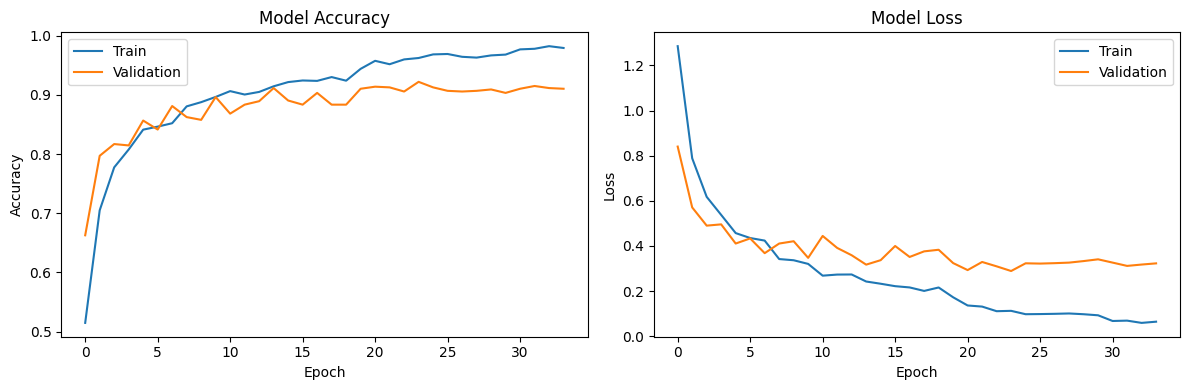

In [7]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(hist.history['accuracy'], label='Train')
plt.plot(hist.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(hist.history['loss'], label='Train')
plt.plot(hist.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

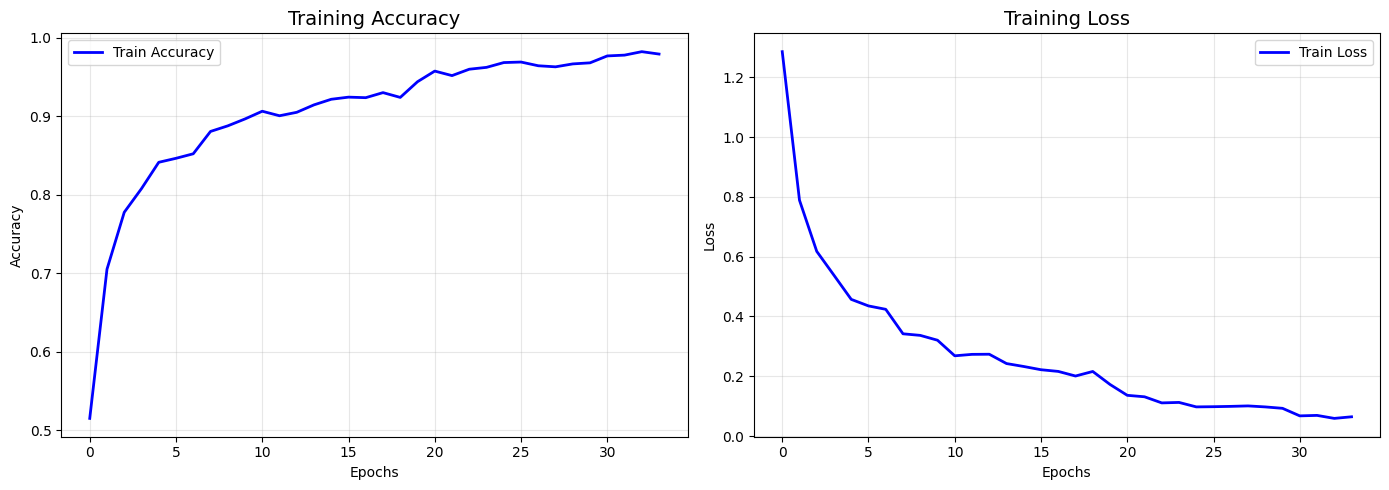

In [8]:
# Plot training history
# ---------------------------
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 5))

# Training Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(hist.history['accuracy'], label='Train Accuracy', linewidth=2, color='blue')
plt.title('Training Accuracy', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Training Loss Plot
plt.subplot(1, 2, 2)
plt.plot(hist.history['loss'], label='Train Loss', linewidth=2, color='blue')
plt.title('Training Loss', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

TEST METRICS
--------------------------------------------------
Accuracy : 0.8865
Precision: 0.8884
Recall   : 0.8865
F1-score : 0.8865

Classification Report:
                       precision    recall  f1-score   support

Bacterial Leaf Blight       0.89      0.97      0.93        72
           Brown Spot       0.92      0.86      0.89        78
    Healthy Rice Leaf       0.92      0.91      0.91        64
           Leaf Blast       0.83      0.88      0.85        83
           Leaf scald       0.85      0.83      0.84        72
        Sheath Blight       0.96      0.87      0.91        54

             accuracy                           0.89       423
            macro avg       0.89      0.89      0.89       423
         weighted avg       0.89      0.89      0.89       423



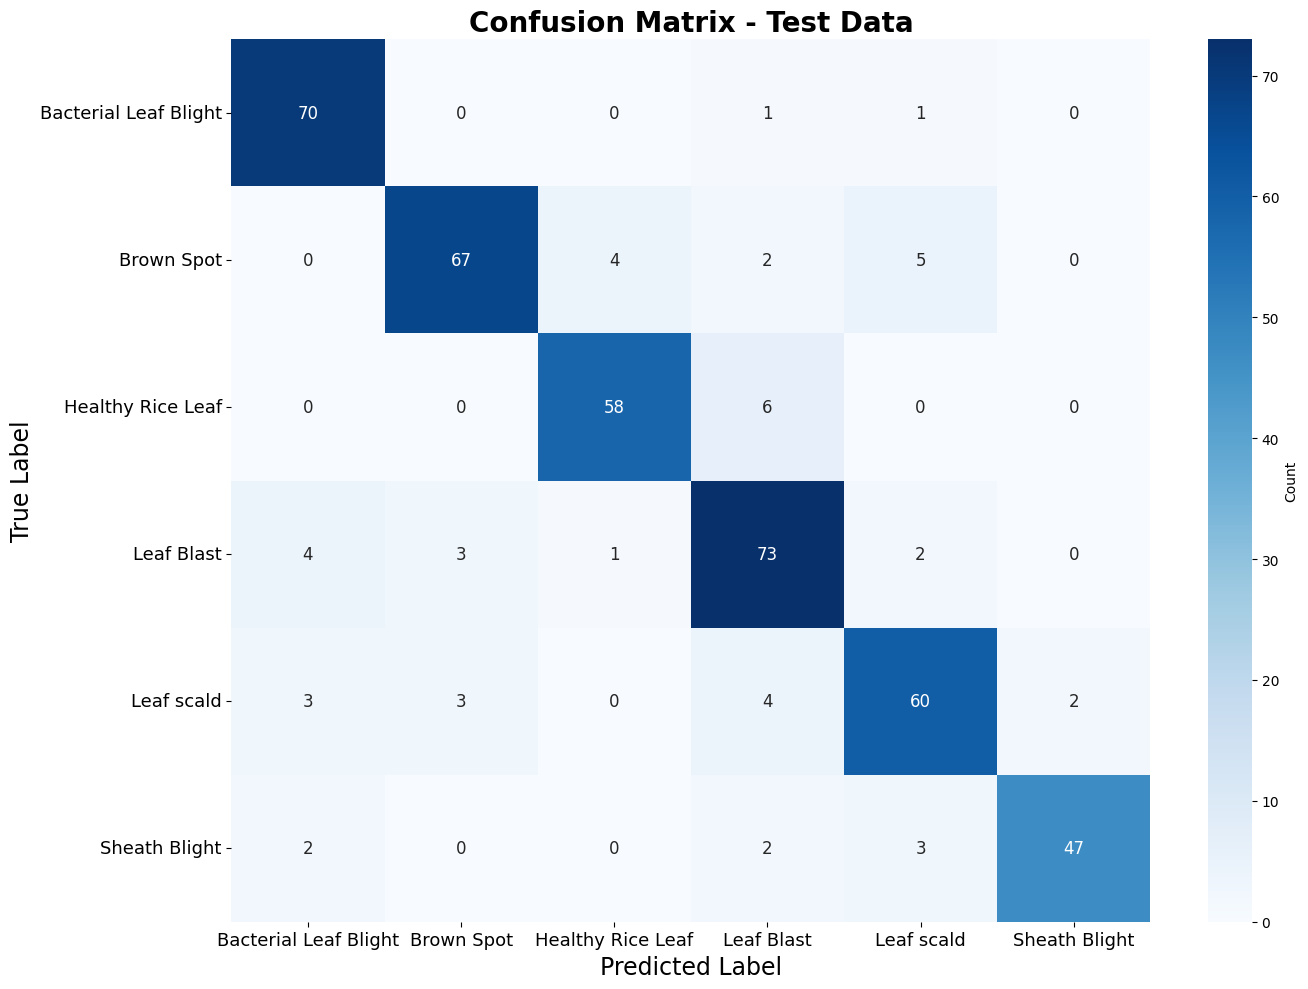

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Predict on test set
test_pred = model.predict(test_x_pp, verbose=0)
test_pred_classes = np.argmax(test_pred, axis=1)

# Metrics
test_accuracy = accuracy_score(test_y, test_pred_classes)
test_precision = precision_score(test_y, test_pred_classes, average="weighted")
test_recall = recall_score(test_y, test_pred_classes, average="weighted")
test_f1 = f1_score(test_y, test_pred_classes, average="weighted")

print("TEST METRICS")
print("-" * 50)
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-score : {test_f1:.4f}")

# Keep labels in exact encoded order
ordered_class_names = [name for name, idx in sorted(label_to_id.items(), key=lambda x: x[1])]

print("\nClassification Report:")
print(classification_report(test_y, test_pred_classes, target_names=ordered_class_names))

# Confusion matrix
cm = confusion_matrix(test_y, test_pred_classes)

# Style similar to your shared figure
plt.figure(figsize=(14, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=ordered_class_names,
    yticklabels=ordered_class_names,
    cbar_kws={"label": "Count"},
    annot_kws={"size": 12}
)

plt.title("Confusion Matrix - Test Data", fontsize=20, fontweight="bold")
plt.xlabel("Predicted Label", fontsize=17)
plt.ylabel("True Label", fontsize=17)
plt.xticks(rotation=0, fontsize=13)
plt.yticks(rotation=0, fontsize=13)
plt.tight_layout()
plt.show()

In [10]:
model.save("densenet121.h5")
print("Saved model to densenet121.h5")

c:\Users\HP\anaconda3\envs\tf\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Saved model to densenet121.h5


In [11]:
model.save("densenet121.keras")
print("Saved model to densenet121.keras")

Saved model to densenet121.keras
